In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from sklearn.decomposition import PCA

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [2]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


# Metricas

In [3]:
# def compute_lof_metrics(df: pd.DataFrame):
#     """
#     Calcula métricas estándar para LOF
#     """

#     df_eval = df.dropna(subset=["anomaly_lof"])

#     total = len(df_eval)
#     anomalies = df_eval["anomaly_lof"].sum()
#     rate = anomalies / total if total else 0

#     metrics = {
#         "total_points": total,
#         "total_anomalies": int(anomalies),
#         "anomaly_rate": rate,
#         "score_mean": df_eval["lof_score"].mean(),
#         "score_std": df_eval["lof_score"].std(),
#         "score_p95": df_eval["lof_score"].quantile(0.95),
#         "score_p99": df_eval["lof_score"].quantile(0.99),
#         "score_max": df_eval["lof_score"].max()
#     }

#     # Comparación con baseline si existe
#     if "anomaly_simple" in df.columns:
#         overlap = (
#             (df_eval["anomaly_lof"]) &
#             (df_eval["anomaly_simple"])
#         ).sum()

#         metrics["baseline_overlap"] = int(overlap)

#     return metrics

In [4]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

# LOF

In [5]:
def fit_lof(
    df: pd.DataFrame,
    features,
    n_neighbors: int = 20,
    contamination: float = 0.01
):
    """
    Ejecuta LOF y devuelve:
    - df_result con columnas anomaly_lof y lof_score
    - scaler entrenado
    """

    df_model = df.copy()

    # Limpieza básica
    X = (
        df_model[features]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    idx = X.index

    # Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # LOF
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination
    )

    pred = lof.fit_predict(X_scaled)
    lof_score = -lof.negative_outlier_factor_

    # Reinyectar resultados
    df_model["anomaly_lof"] = np.nan
    df_model["lof_score"] = np.nan

    df_model.loc[idx, "anomaly_lof"] = (pred == -1)
    df_model.loc[idx, "lof_score"] = lof_score

    return df_model, scaler

In [6]:
# def lof_k_sweep_with_metrics(
#     df: pd.DataFrame,
#     features,
#     k_values,
#     contamination: float = 0.01
# ):
#     """
#     Corre fit_lof() para cada k en k_values y calcula métricas usando compute_lof_metrics().
#     Devuelve:
#       - metrics_df: dataframe con métricas por k
#       - df_by_k: diccionario {k: df_con_resultados}
#     """
#     metrics_list = []
#     df_by_k = {}

#     for k in k_values:
#         df_lof, _ = fit_lof(
#             df=df,
#             features=features,
#             n_neighbors=k,
#             contamination=contamination
#         )

#     #     m = compute_lof_metrics(df_lof)
#     #     m["k"] = k  # agregar k para identificar
#     #     metrics_list.append(m)

#     #     df_by_k[k] = df_lof

#     # metrics_df = pd.DataFrame(metrics_list).sort_values("k").reset_index(drop=True)
#     return df_by_k #metrics_df, 

In [7]:
def lof_k_sweep_with_metrics(
    df: pd.DataFrame,
    features,
    k_values,
    contamination: float = 0.01
):
    metrics_list = []
    df_by_k = {}

    for k in k_values:
        df_lof, _ = fit_lof(
            df=df,
            features=features,
            n_neighbors=k,
            contamination=contamination
        )

        m = evaluar_modelo(
            df_result=df_lof,
            anomaly_col="anomaly_lof",
            score_col="lof_score",
            zscore_col="anomaly_simple"
        )

        m["k"] = k
        metrics_list.append(m)

        df_by_k[k] = df_lof

    metrics_df = pd.concat(metrics_list, ignore_index=True)
    metrics_df = metrics_df.sort_values("k").reset_index(drop=True)

    return metrics_df, df_by_k

# Graficas

In [8]:
def plot_k_sensitivity(df_k):
    plt.figure()
    plt.plot(df_k["k"], df_k["anomaly_rate"])
    plt.title("Sensibilidad de LOF al número de vecinos (k)")
    plt.xlabel("k")
    plt.ylabel("Anomaly Rate")
    plt.show()

In [9]:
def plot_lof_results(
    df: pd.DataFrame,
    time_col: str = "open_time",
    price_col: str = "close"
):
    """
    Genera 3 gráficas:
    - Precio con anomalías
    - LOF score en el tiempo
    - Histograma del score
    """

    df_plot = df.dropna(subset=["anomaly_lof"])

    # Precio + anomalías
    plt.figure()
    plt.plot(df_plot[time_col], df_plot[price_col])
    anomalies = df_plot[df_plot["anomaly_lof"] == True]
    plt.scatter(anomalies[time_col], anomalies[price_col])
    plt.title("Precio con anomalías detectadas por LOF")
    plt.show()

    # LOF score en el tiempo
    plt.figure()
    plt.plot(df_plot[time_col], df_plot["lof_score"])
    plt.title("LOF Score en el tiempo")
    plt.show()

    # Histograma
    plt.figure()
    plt.hist(df_plot["lof_score"].dropna(), bins=50)
    plt.title("Distribución del LOF Score")
    plt.show()

In [10]:
# def plot_lof_pca(df, features):
#     """
#     Proyecta las features a 2D usando PCA
#     y colorea anomalías LOF.
#     """

#     df_plot = df.dropna(subset=["anomaly_lof"])

#     X = df_plot[features]

#     # PCA a 2 dimensiones
#     pca = PCA(n_components=2)
#     X_pca = pca.fit_transform(X)

#     plt.figure()
    
#     normal = df_plot["anomaly_lof"] == False
#     anomaly = df_plot["anomaly_lof"] == True

#     plt.scatter(X_pca[normal, 0], X_pca[normal, 1])
#     plt.scatter(X_pca[anomaly, 0], X_pca[anomaly, 1])

#     plt.title("LOF en espacio reducido (PCA)")
#     plt.show()

def plot_lof_pca_score(
    df,
    features,
    score_col: str = "lof_score",
    title: str = "LOF (PCA 2D) coloreado por score",
    standardize_before_pca: bool = True,
    cmap: str = "RdYlGn_r"
):
    """
    Proyecta features a 2D con PCA y colorea cada punto con el score (ej. lof_score).
    Requiere que df ya tenga score_col calculado (por fit_lof / run_lof).
    """

    d = df.dropna(subset=features + [score_col]).copy()

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]  # alinear
    scores = d[score_col].values

    if standardize_before_pca:
        Xp = StandardScaler().fit_transform(X.values)
    else:
        Xp = X.values

    pca = PCA(n_components=2)
    X2 = pca.fit_transform(Xp)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    

In [11]:
def plot_multiple_lof_pca(df_by_k, features, k_list):

    for k in k_list:

        plot_lof_pca_score(
            df=df_by_k[k],
            features=features,
            score_col="lof_score",
            title=f"LOF PCA score (k={k})"
        )

# features

In [12]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]
k_values = [5, 10, 20, 40, 80, 120]

In [13]:
df_clean = df.copy()

# 1) quitar inf
df_clean[features] = df_clean[features].replace([np.inf, -np.inf], np.nan)

# 2) eliminar filas con NA en features
df_clean = df_clean.dropna(subset=features).reset_index(drop=True)

# k = n

In [14]:
metrics_df, df_by_k = lof_k_sweep_with_metrics(
    df=df,
    features=features,
    k_values=k_values,
    contamination=0.01
)

C:\Users\cecil\AppData\Local\Temp\ipykernel_27720\19785240.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_model.loc[idx, "anomaly_lof"] = (pred == -1)
C:\Users\cecil\AppData\Local\Temp\ipykernel_27720\19785240.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_model.loc[idx, "anomaly_lof"] = (pred == -1)
C:\Users\cecil\AppData\Local\Temp\ipykernel_27720\19785240.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ True False False ... False False False]' has dtyp

In [ ]:
metrics_list = []

for k, df_lof in df_by_k.items():
    m = evaluar_modelo(
        df_result=df_lof,
        anomaly_col="anomaly_lof",
        score_col="lof_score",
        zscore_col="anomaly_simple"
    )
    
    m["k"] = k
    metrics_list.append(m)

metrics_lof_k = pd.concat(metrics_list, ignore_index=True)
metrics_lof_k = metrics_lof_k.sort_values("k").reset_index(drop=True)

metrics_lof_k

,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_min,score_p50,score_p95,score_p99,score_max,zscore_total_anomalias,overlap_zscore_n,overlap_zscore_pct,k
0,281097,2811,0.01,1.039523,0.071484,0.879414,1.023030,1.166084,1.311059,4.329217,4819,236,0.048973,5
1,281097,2811,0.01,1.034629,0.062147,0.922487,1.018115,1.143295,1.275674,4.608556,4819,280,0.058103,10
2,281097,2811,0.01,1.035190,0.062723,0.951971,1.017321,1.144315,1.280044,5.668416,4819,308,0.063914,20
3,281097,2811,0.01,1.038404,0.067748,0.958824,1.018835,1.154228,1.299593,6.915214,4819,318,0.065989,40
4,281097,2811,0.01,1.043363,0.075730,0.962538,1.021650,1.170558,1.333171,7.850592,4819,370,0.076779,80
5,281097,2811,0.01,1.046966,0.081983,0.959878,1.023788,1.182268,1.357952,8.908764,4819,408,0.084665,120


: 

# Overlap con Z-score según k

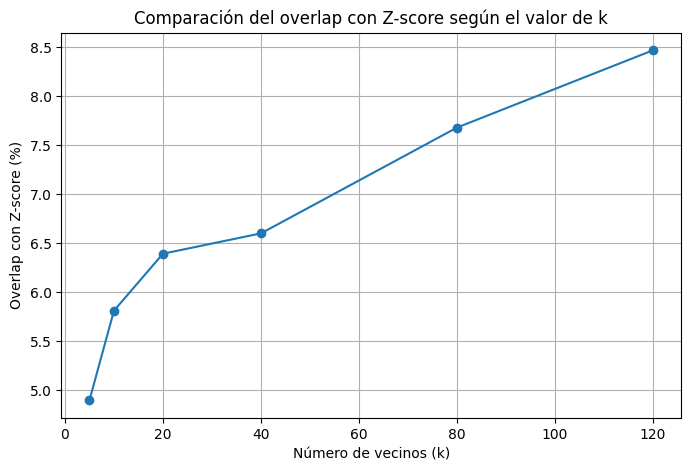

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    metrics_lof_k["k"],
    metrics_lof_k["overlap_zscore_pct"] * 100,
    marker="o"
)

plt.xlabel("Número de vecinos (k)")
plt.ylabel("Overlap con Z-score (%)")
plt.title("Comparación del overlap con Z-score según el valor de k")
plt.grid(True)
plt.show()

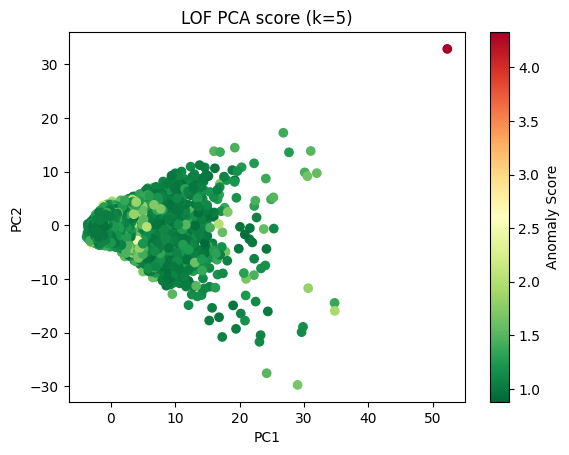

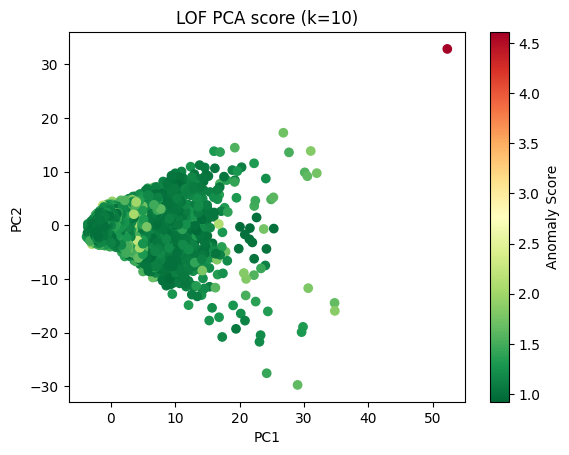

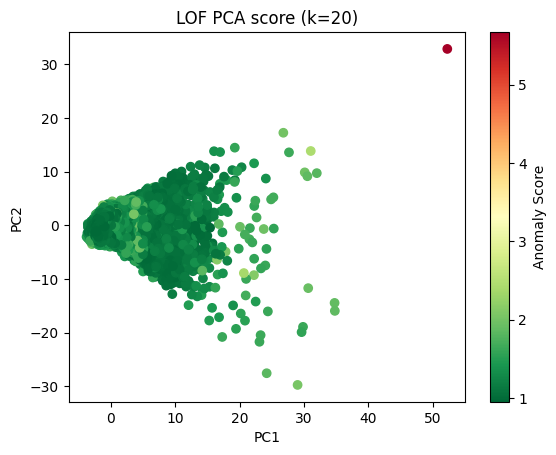

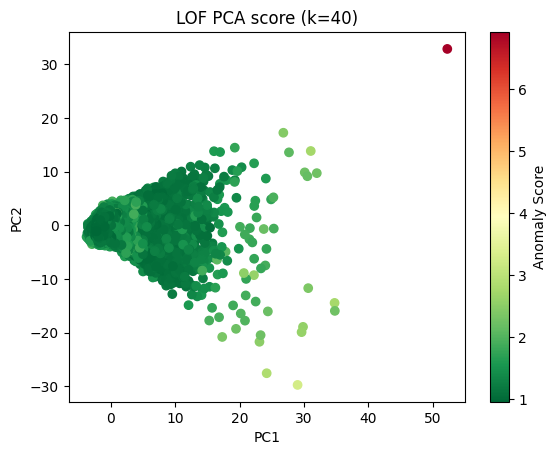

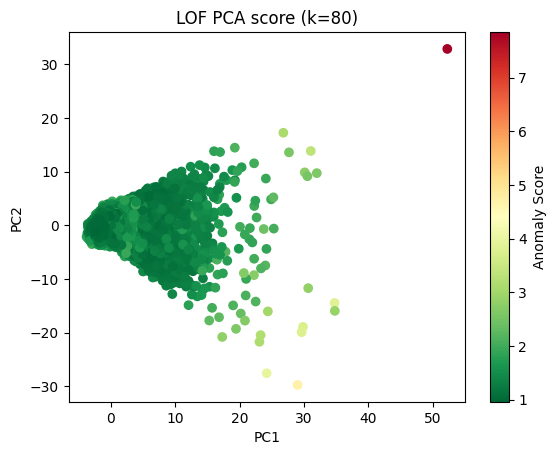

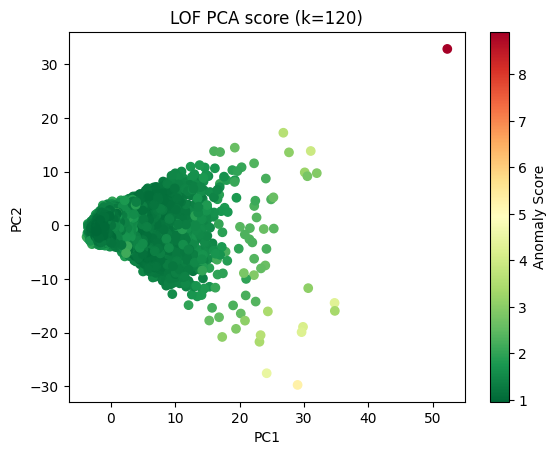

In [27]:
plot_multiple_lof_pca(
    df_by_k=df_by_k,
    features=features,
    k_list=[5, 10, 20, 40, 80, 120]
)